# Import and setup

In [1]:
import os, torch, torch.nn as nn, torch.optim as optim, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import glob, librosa
import timm
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tabulate import tabulate
from IPython.display import clear_output
import torchaudio, torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('No GPU detected')

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.44 GB


# Prepare Data for EDA

In [3]:
%cd D:\project\apisacoustic

D:\project\apisacoustic


In [4]:
csv_frdr = r"dataset\urban-frdr\inspections_2022.csv"
csv_zenodo = r"dataset\zenodo\state_labels.csv"
frdr_audiofolder_path = r"dataset/urban-frdr/audio_2022_all_chunk"
zenodo_audiofolder_path = r"dataset\zenodo"

### checking status

In [5]:
df_frdr = pd.read_csv(csv_frdr)
target = df_frdr[(df_frdr['Queen status'] == 'queenless') | (df_frdr['Category'] == 'varroa')]
# print(target[['Date', 'Tag number', 'Category', 'Queen status']])

### check status on downloaded chuck

In [6]:
all_files = os.listdir(frdr_audiofolder_path)
extract_list = []
for file_path in all_files:
    if file_path.endswith('.wav'):
        file_name = file_path.split('/')[-1]
        parts = file_name.split('_')
        date = parts[0]
        hive_part = parts[2]
        hive_id = hive_part.split('-')[1].split('.')[0]
        for_merge = pd.to_datetime(date, format='%d-%m-%Y').strftime('%Y-%m-%d')
        extract_list.append({'Filename': file_name, 'Date': for_merge, 'Tag number': int(hive_id)})

df_audio = pd.DataFrame(extract_list)
df_audio['Tag number'] = df_audio['Tag number'].astype(int)

df_frdr['Tag number'] = df_frdr['Tag number'].astype(int)
df_frdr['Date'] = pd.to_datetime(df_frdr['Date']).dt.strftime('%Y-%m-%d')

df_frdr_sorted = df_frdr.sort_values(by=['Date', 'Tag number', 'Category'], ascending=[True, True, False])
df_frdr_clean = df_frdr_sorted.drop_duplicates(subset=['Date', 'Tag number'], keep='first')
merge_df = pd.merge(df_audio, df_frdr_clean, on=['Date', 'Tag number'], how='inner')

def check_class(row):
    if row['Category'] == 'varroa':
        return 'Class 2: Infested'
    elif row['Queen status'] == 'queenless':
        return 'Class 1: Queenless'
    elif row['Queen status'] == 'queenright' and row['Is alive'] == 1:
        return 'Class 0: Active'
    else:
        return 'Others / Ignored'
merge_df['target_Class'] = merge_df.apply(check_class, axis=1)
print(merge_df['target_Class'].value_counts())

target_Class
Class 2: Infested     162
Class 0: Active       147
Class 1: Queenless     83
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

### Compare noise level (Active)

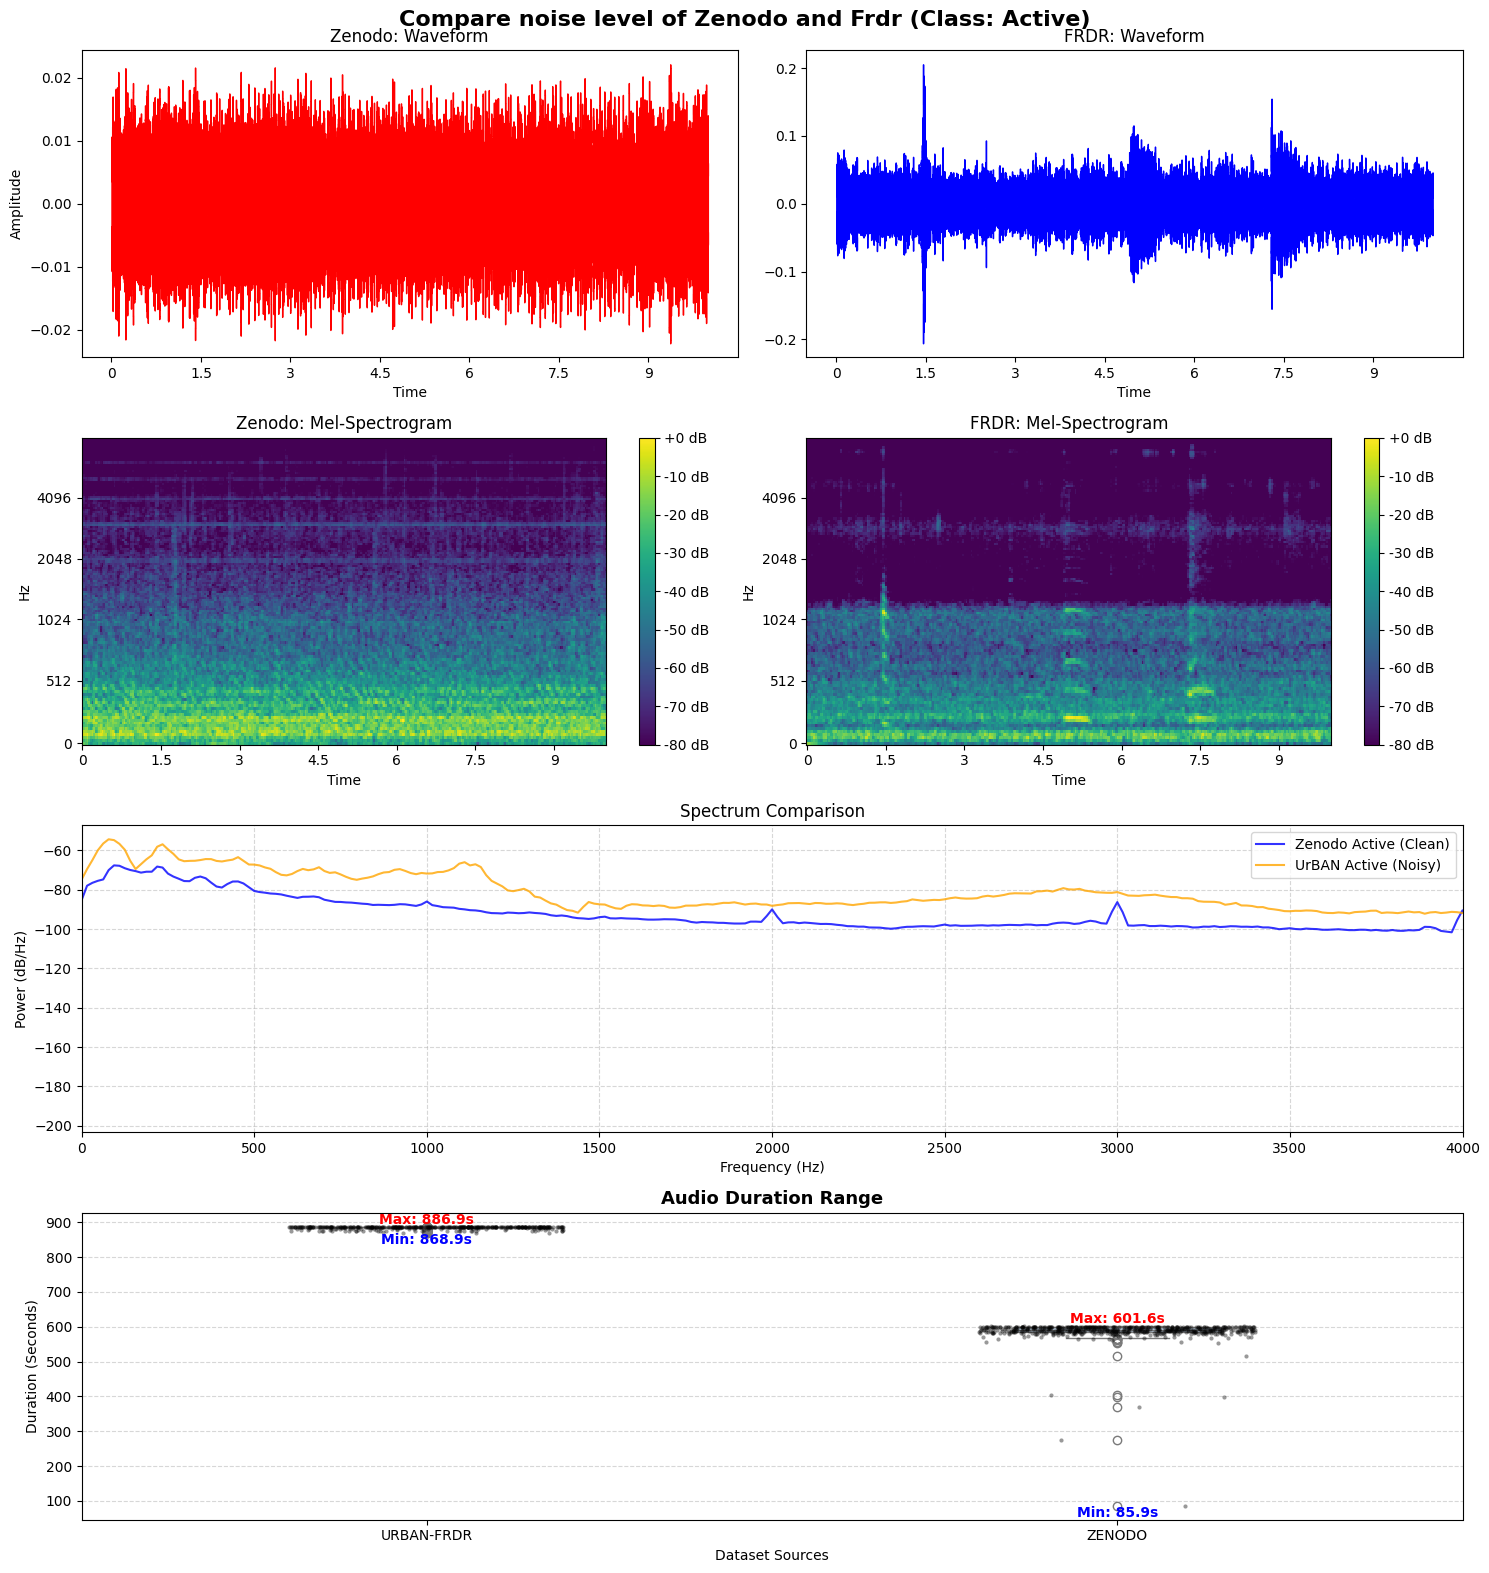

In [7]:
zenodo_active_path = r"dataset\zenodo\Hive1_12_06_2018\Hive1 12_06_2018_QueenBee____00_00_00.wav"
frdr_active_path = r"dataset\urban-frdr\audio_2022_all_chunk\01-09-2022_20h30_HIVE-3693_Active.wav"

sr = 16000
audio_zenodo, sr_z = librosa.load(zenodo_active_path, sr=sr)
audio_frdr, sr_f = librosa.load(frdr_active_path, sr=sr)

duration = 10
audio_zenodo = audio_zenodo[:sr * duration]
audio_frdr = audio_frdr[:sr * duration]

all_audio_files = glob.glob(r"dataset\**\*.wav", recursive=True)

all_duration_data = []
for path in all_audio_files:
    filename = os.path.basename(path)
    dataset_name = None
    filename_lower = filename.lower()
    if any(s in filename_lower for s in ["_active", "_queenless", "_infested"]):
        dataset_name = 'URBAN-FRDR'
    elif any(s in filename_lower for s in ["queenbee", "no_queenbee"]):
        dataset_name = 'ZENODO'
    if dataset_name:
        try:
            file_duration = librosa.get_duration(path=path)
            all_duration_data.append({'Dataset': dataset_name, 'Duration': file_duration})
        except Exception as e:
            print(f"Error reading {filename}: {e}")

df_durations = pd.DataFrame(all_duration_data)

fig, axs = plt.subplots(4, 2, figsize=(15, 16), sharex=False)
fig.suptitle("Compare noise level of Zenodo and Frdr (Class: Active)", fontsize=16, fontweight='bold')
axs[0, 0].set_title("Zenodo: Waveform")
librosa.display.waveshow(audio_zenodo, sr=sr, ax=axs[0, 0], color='red')
axs[0, 0].set_ylabel("Amplitude")
axs[0, 1].set_title("FRDR: Waveform")
librosa.display.waveshow(audio_frdr, sr=sr, ax=axs[0, 1], color='blue')

mel_zenodo = librosa.feature.melspectrogram(y=audio_zenodo, sr=sr, n_mels=128)
mel_db_zenodo = librosa.amplitude_to_db(mel_zenodo, ref=np.max)
axs[1, 0].set_title("Zenodo: Mel-Spectrogram")
img1 = librosa.display.specshow(mel_db_zenodo, sr=sr, x_axis='time', y_axis='mel', ax=axs[1, 0], cmap='viridis')
fig.colorbar(img1, ax=axs[1,0], format='%+2.0f dB')

mel_frdr = librosa.feature.melspectrogram(y=audio_frdr, sr=sr, n_mels=128)
mel_db_frdr = librosa.amplitude_to_db(mel_frdr, ref=np.max)
axs[1, 1].set_title("FRDR: Mel-Spectrogram")
img2 = librosa.display.specshow(mel_db_frdr, sr=sr, x_axis='time', y_axis='mel', ax=axs[1, 1], cmap='viridis')
fig.colorbar(img2, ax=axs[1,1], format='%+2.0f dB')

from scipy.signal import welch
freqs_z, psd_z = welch(audio_zenodo, sr, nperseg=1024)
freqs_u, psd_u = welch(audio_frdr, sr, nperseg=1024)
axs[2, 0].remove(); axs[2, 1].remove()
ax_psd = fig.add_subplot(4, 1, 3)
ax_psd.plot(freqs_z, 10 * np.log10(psd_z), label='Zenodo Active (Clean)', color='blue', alpha=0.8)
ax_psd.plot(freqs_u, 10 * np.log10(psd_u), label='UrBAN Active (Noisy)', color='orange', alpha=0.8)
ax_psd.set_title("Spectrum Comparison"); ax_psd.set_xlabel("Frequency (Hz)"); ax_psd.set_ylabel("Power (dB/Hz)")
ax_psd.set_xlim(0, 4000); ax_psd.grid(True, linestyle='--', alpha=0.5); ax_psd.legend()

axs[3, 0].remove(); axs[3, 1].remove()
ax_duration = fig.add_subplot(4, 1, 4)
if len(df_durations) > 0:
    sns.boxplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, palette='Pastel1', width=0.3, hue='Dataset', legend=False)
    sns.stripplot(data=df_durations, x='Dataset', y='Duration', ax=ax_duration, color='black', size=3, alpha=0.4, jitter=0.2)
    for i, dn in enumerate(['URBAN-FRDR', 'ZENODO']):
        sub = df_durations[df_durations['Dataset'] == dn]['Duration']
        if len(sub) > 0:
            ax_duration.text(i, sub.max(), f"Max: {sub.max():.1f}s", ha='center', va='bottom', color='red', fontweight='bold', fontsize=10)
            ax_duration.text(i, sub.min(), f"Min: {sub.min():.1f}s", ha='center', va='top', color='blue', fontweight='bold', fontsize=10)
ax_duration.set_title("Audio Duration Range", fontsize=13, fontweight='bold')
ax_duration.set_xlabel("Dataset Sources"); ax_duration.set_ylabel("Duration (Seconds)")
ax_duration.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [8]:
too_short = df_durations[
    (df_durations['Dataset'] == 'ZENODO') &
    (df_durations['Duration'] < 500)
]
if len(too_short) > 0:
    print(f"Too short found: {len(too_short)} File\n")
    for idx, row in too_short.iterrows():
        target_duration = row['Duration']
        for path in all_audio_files:
            if "queenbee" in path.lower() or "no_queenbee" in path.lower():
                try:
                    d = librosa.get_duration(path=path)
                    if abs(d - target_duration) < 0.1:
                        found_filename = os.path.basename(path); break
                except: pass
        print(f"File name: {found_filename}")
        print(f"Duration: {target_duration:.2f} Sec (About {target_duration/60:.1f} Min)")
else:
    print("Not found")

Too short found: 5 File

File name: Hive3_14_07_2017_NO_QueenBee____07_30_00.wav
Duration: 274.00 Sec (About 4.6 Min)
File name: Hive3_14_07_2017_NO_QueenBee____09_30_00.wav
Duration: 397.06 Sec (About 6.6 Min)
File name: Hive3_28_07_2017_QueenBee____07_40_00.wav
Duration: 369.20 Sec (About 6.2 Min)
File name: Hive3_28_07_2017_QueenBee____11_30_00.wav
Duration: 402.52 Sec (About 6.7 Min)
File name: Hive3_28_07_2017_QueenBee____12_40_00.wav
Duration: 85.91 Sec (About 1.4 Min)


In [9]:
frdr_hives = df_audio['Tag number'].unique()
total_frdr_hives = len(frdr_hives)
print(f"Total FRDR Hive: {total_frdr_hives} hives")
print(f"FRDR Name list: {sorted(frdr_hives)}")
counts = df_audio['Tag number'].value_counts().sort_index()
print(f"Total FRDR Hive: {total_frdr_hives} hives")
print("Files per hive:")
for hive, cnt in counts.items():
    print(f"  Hive {hive}: {cnt} files")

Total FRDR Hive: 9 hives
FRDR Name list: [np.int64(6), np.int64(3627), np.int64(3628), np.int64(3631), np.int64(3640), np.int64(3690), np.int64(3691), np.int64(3692), np.int64(3693)]
Total FRDR Hive: 9 hives
Files per hive:
  Hive 6: 100 files
  Hive 3627: 5 files
  Hive 3628: 31 files
  Hive 3631: 65 files
  Hive 3640: 41 files
  Hive 3690: 65 files
  Hive 3691: 15 files
  Hive 3692: 4 files
  Hive 3693: 67 files


# Data split

In [10]:
def split_data(df, stratify_col):
    if stratify_col in df.columns:
        stratify_vals = df[stratify_col]
    else:
        stratify_vals = None
    if stratify_vals is not None:
        counts = stratify_vals.value_counts()
        if counts.min() < 2:
            stratify_vals = None
    if len(df) < 10:
        if stratify_vals is not None:
            train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=stratify_vals)
        else:
            train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
        if stratify_vals is not None and stratify_col in temp_df.columns and temp_df[stratify_col].nunique() > 1:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df[stratify_col])
        else:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
        return train_df, val_df, test_df
    if stratify_vals is not None:
        train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=stratify_vals)
    else:
        train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
    if stratify_vals is not None and stratify_col in temp_df.columns:
        counts_temp = temp_df[stratify_col].value_counts()
        if counts_temp.min() < 2:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
        else:
            val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df[stratify_col])
    else:
        val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
    return train_df, val_df, test_df

In [11]:
frdr_files = glob.glob(os.path.join(frdr_audiofolder_path, "*.wav"))
frdr_data = []
for path in frdr_files:
    filename = os.path.basename(path)
    if any(suffix in filename for suffix in ["_Active", "_Queenless", "_Infested"]):
        name_part, _ = os.path.splitext(filename)
        parts = name_part.split('_')
        class_label = parts[-1]
        hive_id = "Unknown"
        for p in parts:
            if "HIVE" in p: hive_id = p; break
        frdr_data.append({'File_Path': path, 'Filename': filename, 'Dataset': 'FRDR', 'Class': class_label, 'Hive': hive_id})
df_frdr_all = pd.DataFrame(frdr_data)

zenodo_files = glob.glob(os.path.join(zenodo_audiofolder_path, "*", "*.wav"))
zenodo_data = []
for path in zenodo_files:
    filename = os.path.basename(path)
    folder_name = os.path.basename(os.path.dirname(path))
    if "NO_QueenBee" in filename: class_label = "Queenless"
    elif "QueenBee" in filename: class_label = "Active"
    else: continue
    hive_id = folder_name.split('_')[0]
    zenodo_data.append({'File_Path': path, 'Filename': filename, 'Dataset': 'ZENODO', 'Class': class_label, 'Hive': hive_id})
df_zenodo_all = pd.DataFrame(zenodo_data)

print(f"UrBAN-FRDR: {len(df_frdr_all)} Files")
print(f"Zenodo: {len(df_zenodo_all)} Files")

zenodo_train_list, zenodo_val_list, zenodo_test_list = [], [], []
for folder, group in df_zenodo_all.groupby('Dataset'):
    z_train, z_val, z_test = split_data(group, stratify_col='Class')
    zenodo_train_list.append(z_train); zenodo_val_list.append(z_val); zenodo_test_list.append(z_test)
train_zenodo = pd.concat(zenodo_train_list) if len(zenodo_train_list) > 0 else pd.DataFrame()
val_zenodo = pd.concat(zenodo_val_list) if len(zenodo_val_list) > 0 else pd.DataFrame()
test_zenodo = pd.concat(zenodo_test_list) if len(zenodo_test_list) > 0 else pd.DataFrame()

df_frdr_all['Stratify_Key'] = df_frdr_all['Class'] + "_" + df_frdr_all['Hive']
counts = df_frdr_all['Stratify_Key'].value_counts()
rare_keys = counts[counts < 10].index
df_frdr_all['Stratify_Key'] = df_frdr_all['Stratify_Key'].apply(lambda x: x.split('_')[0] if x in rare_keys else x)
train_frdr, val_frdr, test_frdr = split_data(df_frdr_all, stratify_col='Stratify_Key')

train_df = pd.concat([train_zenodo, train_frdr], ignore_index=True)
val_df = pd.concat([val_zenodo, val_frdr], ignore_index=True)
test_df = pd.concat([test_zenodo, test_frdr], ignore_index=True)
for df in [train_df, val_df, test_df]:
    df.drop(columns=['Stratify_Key'], errors='ignore', inplace=True)

print(f"Total files: Train = {len(train_df)} | Val = {len(val_df)} | Test = {len(test_df)}")
print("\n")
print("1. Split by Dataset:")
summary_dataset = pd.DataFrame({'Train_Set': train_df['Dataset'].value_counts(), 'Val_Set': val_df['Dataset'].value_counts(), 'Test_Set': test_df['Dataset'].value_counts()}).fillna(0).astype(int)
summary_dataset['Total'] = summary_dataset.sum(axis=1)
print(summary_dataset)
print("\n")
print("2. Split by Class:")
summary_class = pd.DataFrame({'Train_Set': train_df['Class'].value_counts(), 'Val_Set': val_df['Class'].value_counts(), 'Test_Set': test_df['Class'].value_counts()}).fillna(0).astype(int)
summary_class['Total'] = summary_class.sum(axis=1)
print(summary_class)
print("\n")
print("3. Split by Hive:")
summary_hive = pd.DataFrame({'Train_Set': train_df['Hive'].value_counts(), 'Val_Set': val_df['Hive'].value_counts(), 'Test_Set': test_df['Hive'].value_counts()}).fillna(0).astype(int)
summary_hive['Total'] = summary_hive.sum(axis=1)
print(summary_hive)

UrBAN-FRDR: 393 Files
Zenodo: 576 Files
Total files: Train = 774 | Val = 97 | Test = 98


1. Split by Dataset:
         Train_Set  Val_Set  Test_Set  Total
Dataset                                     
ZENODO         460       58        58    576
FRDR           314       39        40    393


2. Split by Class:
           Train_Set  Val_Set  Test_Set  Total
Class                                         
Active           346       45        44    435
Queenless        297       36        38    371
Infested         131       16        16    163


3. Split by Hive:
           Train_Set  Val_Set  Test_Set  Total
Hive                                          
HIVE-3627          4        1         0      5
HIVE-3628         25        3         3     31
HIVE-3631         52        4         9     65
HIVE-3640         33        4         4     41
HIVE-3690         52        8         5     65
HIVE-3691         12        1         2     15
HIVE-3692          3        0         1      4
HIVE-3693 

## Slice Audio Data -> 30s

In [12]:
sr = 16000
audit_folder = 'Audit_Noise'
os.makedirs(audit_folder, exist_ok=True)
mel_transform = T.MelSpectrogram(sample_rate=sr, n_fft=1024, hop_length=512, n_mels=128).to(DEVICE)

def make_mel_tensor_gpu(audio_chunk, target_size=(224, 224)):
    if audio_chunk.shape[0] > 1:
        audio_chunk = torch.mean(audio_chunk, dim=0, keepdim=True)
    mel_spec = mel_transform(audio_chunk)
    mel_db = T.AmplitudeToDB()(mel_spec)
    input_tensor = mel_db.unsqueeze(0)
    mel_resized = torch.nn.functional.interpolate(input_tensor, size=target_size, mode='bilinear', align_corners=False).squeeze(0)
    mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(3, 1, 1)
    mel_rgb = mel_resized.repeat(3, 1, 1)
    return (mel_rgb - mean) / std

def audio_chunks(df, is_train=True, chunk_length_s=30, max_eval_chunks=5):
    chunked_data = []
    chunk_len = chunk_length_s * sr
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing chunks"):
        try:
            y_full, file_sr = torchaudio.load(row['File_Path'])
            if file_sr != sr:
                resampler = T.Resample(file_sr, sr).to(DEVICE)
                y_full = resampler(y_full.to(DEVICE))
            else:
                y_full = y_full.to(DEVICE)
            total_chunks = y_full.shape[1] // chunk_len
            if total_chunks == 0: continue
            indices = range(total_chunks) if is_train else np.random.choice(range(total_chunks), min(total_chunks, max_eval_chunks), replace=False)
            for i in indices:
                y = y_full[:, i*chunk_len : (i+1)*chunk_len]
                rms = torch.sqrt(torch.mean(y**2))
                if rms < 0.003:
                    torchaudio.save(os.path.join(audit_folder, f"Noise_{os.path.basename(row['File_Path'])}_{i}.wav"), y.cpu(), sr)
                    continue
                melspec_tensor = make_mel_tensor_gpu(y)
                chunked_data.append({'File_Path': row['File_Path'], 'Class': row['Class'], 'chunk_id': i, 'mel_tensor': melspec_tensor.cpu()})
        except Exception as e:
            print(f"Error: {e}")
            continue
    return pd.DataFrame(chunked_data)

train_chunks_df = audio_chunks(train_df, is_train=True, chunk_length_s=30)
print(f'Train chunks: {len(train_chunks_df)} chunks {len(train_df)} files')
print('Processing validation audio chunks')
val_chunks_df = audio_chunks(val_df, is_train=False, chunk_length_s=30, max_eval_chunks=2)
print(f'Val chunks: {len(val_chunks_df)} chunks {len(val_df)} files')
print('Processing test audio chunks')
test_chunks_df = audio_chunks(test_df, is_train=False, chunk_length_s=30, max_eval_chunks=2)
print(f'Test chunks: {len(test_chunks_df)} chunks {len(test_df)} files')
print(f'\nLabel distribution in chunks')
print(f'Train: {train_chunks_df["Class"].value_counts().to_dict()}')
print(f'Val: {val_chunks_df["Class"].value_counts().to_dict()}')

Processing chunks: 100%|██████████| 774/774 [05:14<00:00,  2.46it/s]


Train chunks: 17371 chunks 774 files
Processing validation audio chunks


Processing chunks: 100%|██████████| 97/97 [00:35<00:00,  2.74it/s]


Val chunks: 188 chunks 97 files
Processing test audio chunks


Processing chunks: 100%|██████████| 98/98 [00:36<00:00,  2.72it/s]

Test chunks: 192 chunks 98 files

Label distribution in chunks
Train: {'Active': 7310, 'Queenless': 6294, 'Infested': 3767}
Val: {'Active': 84, 'Queenless': 72, 'Infested': 32}


In [13]:
def downsample(df, infested_label='Infested', other_labels=('Active', 'Queenless')):
    label_counts = df['Class'].value_counts()
    target_count = int(label_counts.get(infested_label, 0))
    if target_count == 0: return df
    balanced = []
    for label, group in df.groupby('Class'):
        if label in other_labels and len(group) > target_count:
            balanced.append(group.sample(n=target_count, random_state=42))
        else: balanced.append(group)
    balanced_df = pd.concat(balanced, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_df

balanced_train_chunks_df = downsample(train_chunks_df)
balanced_val_chunks_df = downsample(val_chunks_df)
print(balanced_train_chunks_df['Class'].value_counts().to_dict())
print(balanced_val_chunks_df['Class'].value_counts().to_dict())

{'Active': 3767, 'Queenless': 3767, 'Infested': 3767}
{'Queenless': 32, 'Infested': 32, 'Active': 32}


# Model Training

In [ ]:
class LabelSmoothing(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__(); self.smoothing = smoothing
    def forward(self, preds, target):
        n = preds.size(1)
        log_probs = F.log_softmax(preds, dim=1)
        with torch.no_grad():
            true_dist = torch.full_like(log_probs, self.smoothing / (n - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))

class WarmupSchedule:
    def __init__(self, optimizer, warmup_epochs=5, total_epochs=40, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lr = optimizer.param_groups[0]['lr']
        self.epoch = 0
    def step(self):
        self.epoch += 1
        if self.epoch <= self.warmup_epochs:
            lr = self.base_lr * (self.epoch / self.warmup_epochs)
        else:
            progress = (self.epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
        for g in self.optimizer.param_groups:
            g['lr'] = lr
        return lr

def mixup_data(x, y, alpha=0.2):
    if alpha == 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

criterion = LabelSmoothing(smoothing=0.1)

## Dataset with Cutout Augmentation

In [15]:
class ChunkDataset(Dataset):
    def __init__(self, chunks_df, augment=False):
        self.chunks_df = chunks_df.reset_index(drop=True)
        self.label_map = {'Active': 0, 'Queenless': 1, 'Infested': 2}
        self.augment = augment
    def __len__(self):
        return len(self.chunks_df)
    def __getitem__(self, idx):
        row = self.chunks_df.iloc[idx]
        mel_tensor = row['mel_tensor']
        if not isinstance(mel_tensor, torch.Tensor):
            mel_tensor = torch.tensor(mel_tensor, dtype=torch.float32)
        label_str = row['Class']
        label_encoded = self.label_map.get(label_str, 0)
        if self.augment:
            if torch.rand(1) < 0.3:
                mel_tensor = torch.flip(mel_tensor, dims=[2])
            if torch.rand(1) < 0.25:
                h, w = mel_tensor.shape[1], mel_tensor.shape[2]
                eh, ew = int(h*0.15), int(w*0.15)
                y = torch.randint(0, h-eh+1, (1,)).item()
                x = torch.randint(0, w-ew+1, (1,)).item()
                mel_tensor[:, y:y+eh, x:x+ew] = 0
            if torch.rand(1) < 0.3:
                f = torch.randint(0, mel_tensor.shape[1] // 5, (1,)).item()
                f0 = torch.randint(0, mel_tensor.shape[1] - f, (1,)).item()
                mel_tensor[:, f0:f0+f, :] = 0
            if torch.rand(1) < 0.3:
                t = torch.randint(0, mel_tensor.shape[2] // 5, (1,)).item()
                t0 = torch.randint(0, mel_tensor.shape[2] - t, (1,)).item()
                mel_tensor[:, :, t0:t0+t] = 0
            if torch.rand(1) < 0.2:
                noise = torch.randn_like(mel_tensor) * 0.05
                mel_tensor = mel_tensor + noise
        return mel_tensor, torch.tensor(label_encoded, dtype=torch.long)

pin_memory = True if torch.cuda.is_available() else False
train_dataset = ChunkDataset(balanced_train_chunks_df, augment=True)
val_dataset = ChunkDataset(balanced_val_chunks_df)
test_dataset = ChunkDataset(test_chunks_df)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

## Model Definition (with Dropout)

In [ ]:
mobilenet = timm.create_model('mobilenetv4_hybrid_large', pretrained=True, num_classes=3)
in_features = mobilenet.classifier.in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.5), nn.Linear(in_features, 3)
)
print(mobilenet.classifier)
mobilenet = mobilenet.to(DEVICE)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


## Training Loop (Mixup + Grad Clip + Warmup + Early Stopping)

In [ ]:
optimizer = optim.AdamW(mobilenet.parameters(), lr=1e-4, weight_decay=5e-2)

NUM_EPOCHS = 30
USE_MIXUP = True
scheduler = WarmupSchedule(optimizer, warmup_epochs=5, total_epochs=NUM_EPOCHS)

best_val_loss = float('inf')
patience, trigger = 30, 0
results_table = []
headers = ["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc", "LR"]

for epoch in range(NUM_EPOCHS):
    mobilenet.train()
    running_loss, correct, total = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    for images, labels in train_loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if USE_MIXUP:
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)
        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = mixup_criterion(criterion, outputs, y_a, y_b, lam) if USE_MIXUP else criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mobilenet.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        if USE_MIXUP:
            correct += (predicted.eq(y_a) | predicted.eq(y_b)).float().sum().item()
        else:
            correct += predicted.eq(labels).sum().item()
        train_loop.set_postfix(loss=f"{loss.item():.4f}")

    train_loss, train_acc = running_loss / total, correct / total

    mobilenet.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss, val_acc = val_loss / val_total, val_correct / val_total
    lr_val = scheduler.step()

    results_table.append([epoch+1, f"{train_loss:.4f}", f"{train_acc:.4f}", f"{val_loss:.4f}", f"{val_acc:.4f}", f"{lr_val:.2e}"])
    clear_output(wait=True)
    print(tabulate(results_table, headers=headers, tablefmt="simple_outline"))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mobilenet.state_dict(), 'best_mobilenet_model.pth')
        trigger = 0
        print(f"    Saved best model at epoch {epoch+1}")
    else:
        trigger += 1
        if trigger >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

mobilenet.load_state_dict(torch.load('best_mobilenet_model.pth'))
print('Loaded best model weights (from early stopping)')

┌─────────┬──────────────┬─────────────┬────────────┬───────────┬──────────┐
│   Epoch │   Train Loss │   Train Acc │   Val Loss │   Val Acc │       LR │
├─────────┼──────────────┼─────────────┼────────────┼───────────┼──────────┤
│       1 │       0.7769 │      0.8621 │     0.5332 │    0.9062 │ 2e-05    │
│       2 │       0.5961 │      0.9619 │     0.4982 │    0.9479 │ 4e-05    │
│       3 │       0.6016 │      0.9673 │     0.4752 │    0.9792 │ 6e-05    │
│       4 │       0.5872 │      0.9687 │     0.4834 │    0.9583 │ 8e-05    │
│       5 │       0.5899 │      0.9694 │     0.4968 │    0.9583 │ 0.0001   │
│       6 │       0.5841 │      0.97   │     0.4693 │    0.9792 │ 9.98e-05 │
│       7 │       0.5755 │      0.975  │     0.4793 │    0.9583 │ 9.92e-05 │
│       8 │       0.5755 │      0.9759 │     0.4758 │    0.9583 │ 9.82e-05 │
│       9 │       0.5548 │      0.9774 │     0.4623 │    0.9688 │ 9.68e-05 │
│      10 │       0.5483 │      0.9803 │     0.4651 │    0.9688 │ 9.51e-05 │

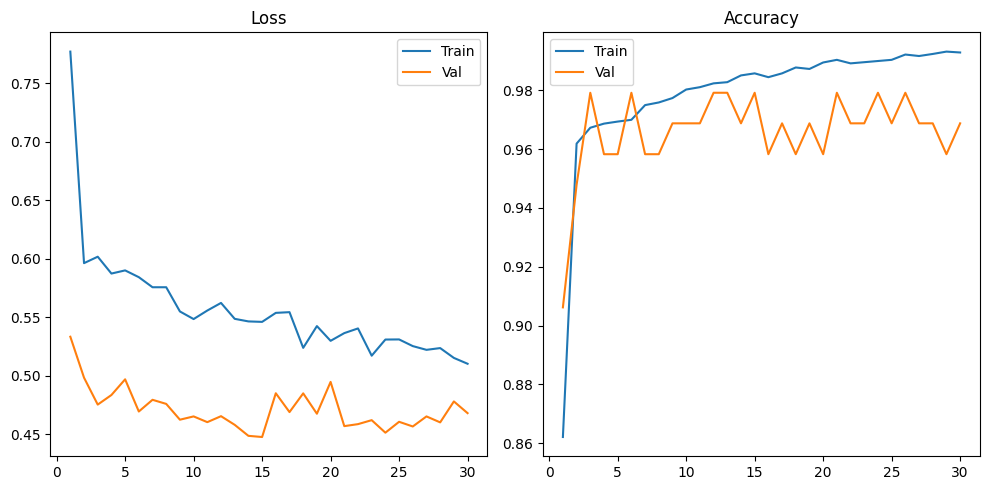

Total Epochs: 30
Best Epoch: 15
Best val loss: 0.4475


In [21]:
results_df = pd.DataFrame(results_table, columns=headers)
cols = ['Train Loss', 'Train Acc', 'Val Loss', 'Val Acc']
for c in cols:
    results_df[c] = results_df[c].astype(float)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(results_df['Epoch'], results_df['Train Loss'], label='Train')
axs[0].plot(results_df['Epoch'], results_df['Val Loss'], label='Val')
axs[0].set_title('Loss'); axs[0].legend()
axs[1].plot(results_df['Epoch'], results_df['Train Acc'], label='Train')
axs[1].plot(results_df['Epoch'], results_df['Val Acc'], label='Val')
axs[1].set_title('Accuracy'); axs[1].legend()

best_idx = results_df['Val Loss'].idxmin()
plt.tight_layout(); plt.show()
print("Total Epochs:", len(results_df))
print("Best Epoch:", results_df.loc[best_idx, 'Epoch'])
print("Best val loss:", results_df.loc[best_idx, 'Val Loss'])

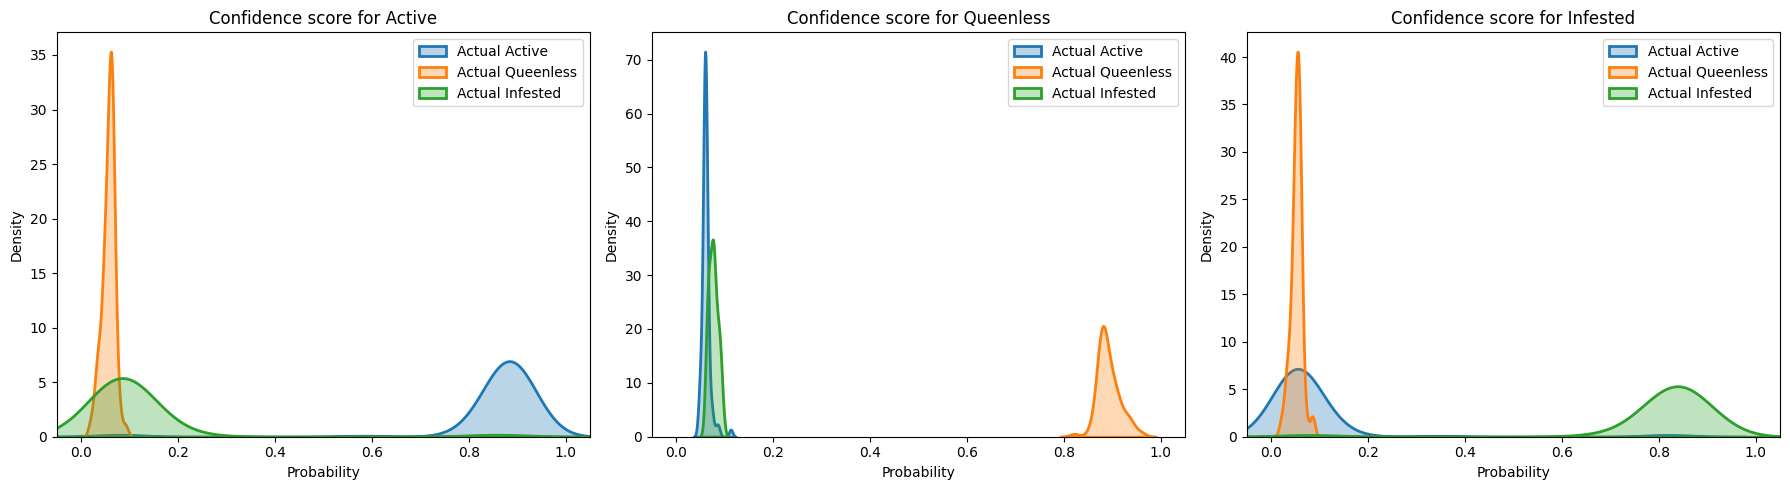

In [22]:
def plot_density(model, loader, device, class_names=['Active', 'Queenless', 'Infested']):
    model.eval()
    all_probs = []; all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    probs = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i in range(3):
        for j in range(3):
            sns.kdeplot(probs[labels == j, i], fill=True, color=colors[j], label=f"Actual {class_names[j]}", ax=axes[i], alpha=0.3, linewidth=2)
        axes[i].set_title(f"Confidence score for {class_names[i]}")
        axes[i].set_xlabel("Probability"); axes[i].set_ylabel("Density"); axes[i].set_xlim(-0.05, 1.05); axes[i].legend()
    plt.tight_layout(); plt.show()

plot_density(mobilenet, test_loader, DEVICE)

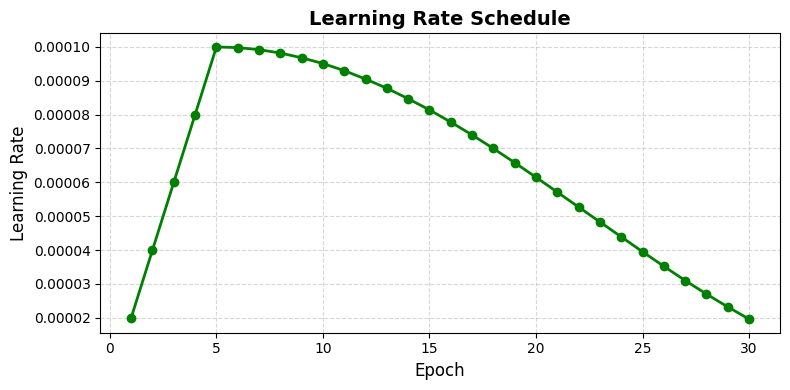

In [24]:
results_df = pd.DataFrame(results_table, columns=headers)
results_df['LR'] = results_df['LR'].astype(float)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['Epoch'], results_df['LR'], marker='o', linestyle='-', color='green', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

============== Classification Report ===============
              precision    recall  f1-score   support

      Active       0.94      1.00      0.97        32
   Queenless       1.00      1.00      1.00        32
    Infested       1.00      0.94      0.97        32

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96



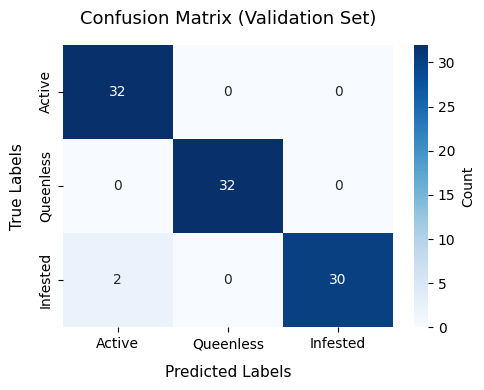

In [23]:
def plot_metrics(model, dataloader, device, class_names, split_name=None):
    model.eval()
    all_preds = []; all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    print("============== Classification Report ===============")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax, cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Labels', fontsize=11, labelpad=10)
    ax.set_ylabel('True Labels', fontsize=11, labelpad=10)
    title = 'Confusion Matrix'
    if split_name: title += f" ({split_name})"
    ax.set_title(title, fontsize=13, pad=15)
    plt.tight_layout(); plt.show()
    return all_preds, all_labels

class_labels = ['Active', 'Queenless', 'Infested']
val_preds, val_labels = plot_metrics(mobilenet, val_loader, DEVICE, class_labels, split_name="Validation Set")